In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("laptop_data.csv")

In [4]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [5]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [6]:
df = df.drop(columns = ["Unnamed: 0"])

In [7]:
df["Ram"] = df["Ram"].str.replace("GB","")
df["Weight"] = df["Weight"].str.replace("kg","")

In [8]:
df["Ram"]=df["Ram"].astype("int64")
df["Weight"]=df["Weight"].astype("float64")

In [9]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


C:\Users\Pcc\AppData\Local\Temp\ipykernel_12540\1344085740.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Price"])


<Axes: xlabel='Price', ylabel='Density'>

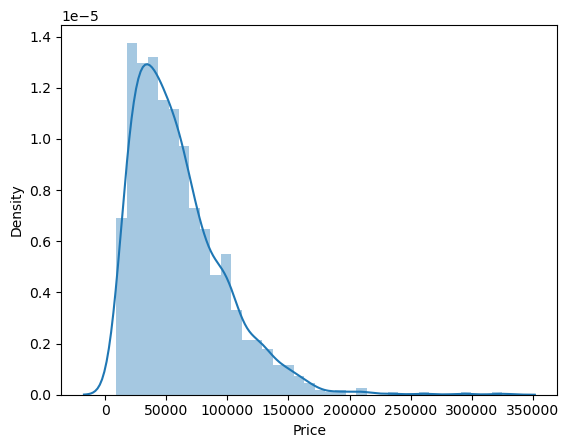

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.distplot(df["Price"])

<Axes: xlabel='Company'>

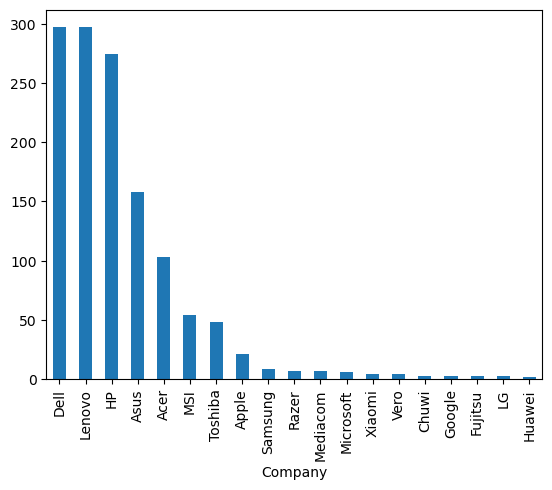

In [11]:
df["Company"].value_counts().plot(kind="bar")

<Axes: xlabel='TypeName', ylabel='Price'>

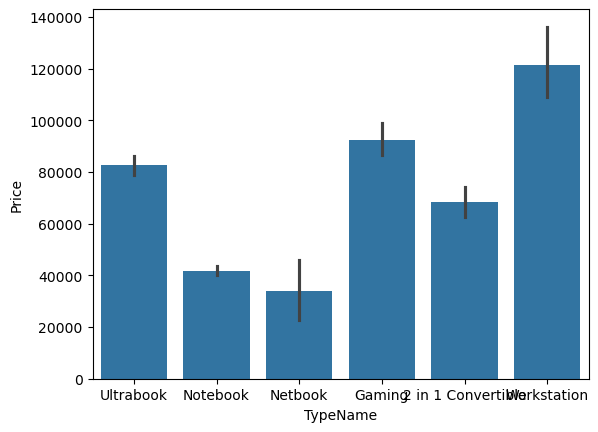

In [12]:
sns.barplot(x=df["TypeName"], y=df["Price"])

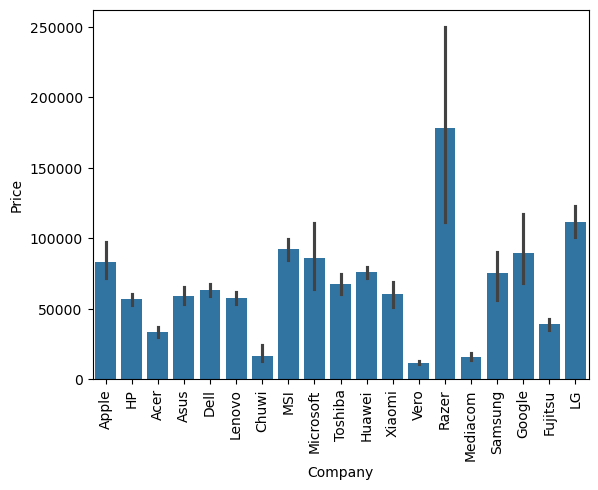

In [13]:
sns.barplot(x=df["Company"], y=df["Price"])
plt.xticks(rotation = 'vertical')
plt.show()

<Axes: xlabel='Inches', ylabel='Price'>

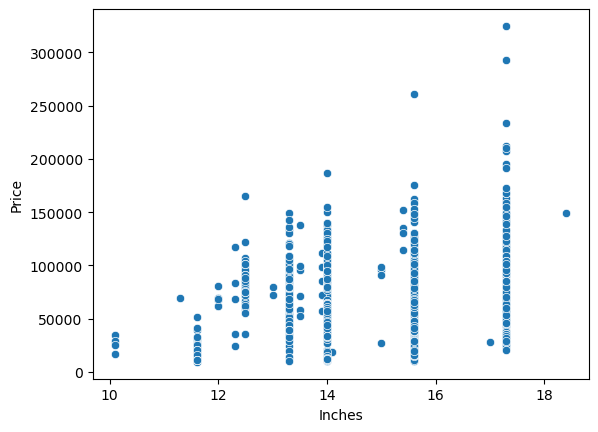

In [14]:
sns.scatterplot(x=df["Inches"], y=df["Price"])

In [15]:
df.head()
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [16]:
df["touchscreen"] = df["ScreenResolution"].apply(lambda x : 1 if "Touchscreen" in x else 0)

<Axes: xlabel='touchscreen', ylabel='Price'>

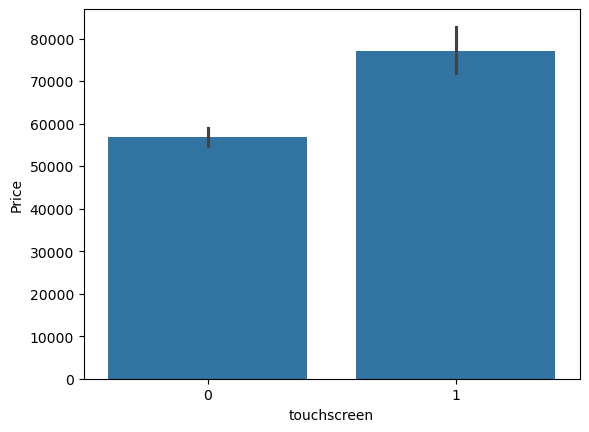

In [17]:
sns.barplot(x = df["touchscreen"] , y = df["Price"])

In [18]:
df["IPS Panel"] = df["ScreenResolution"].apply(lambda x : 1 if "IPS Panel" in x else 0)

<Axes: xlabel='IPS Panel', ylabel='Price'>

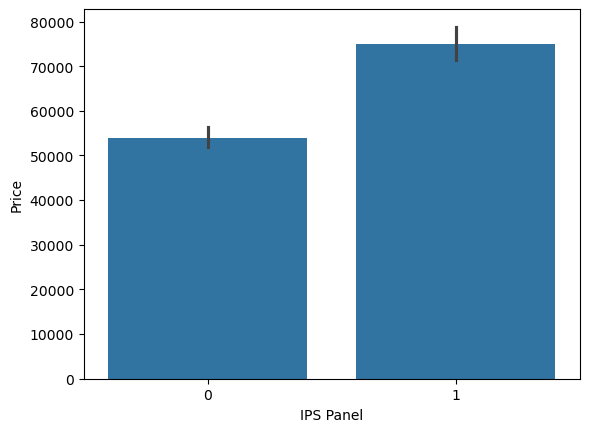

In [19]:
sns.barplot(x = df["IPS Panel"] , y = df["Price"])

In [20]:
new = df["ScreenResolution"].str.split("x", n=1, expand = True)

In [21]:
df["x_res"] = new[0]
df["y_res"] = new[1]

In [22]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,touchscreen,IPS Panel,x_res,y_res
887,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,12,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,72988.272,0,0,Full HD 1920,1080
336,Dell,Ultrabook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce 940MX,Windows 10,1.90,55890.720,0,1,IPS Panel Full HD 1920,1080
647,Razer,Gaming,14.0,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD,Nvidia GeForce GTX 1060,Windows 10,1.95,138474.720,0,0,Full HD 1920,1080
616,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4,128GB SSD,AMD Radeon R5 M420,Linux,2.18,30316.320,0,0,Full HD 1920,1080
981,Toshiba,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4,128GB SSD,Intel HD Graphics 520,Windows 7,1.20,63669.600,0,0,Full HD 1920,1080


In [23]:
df["x_res"] = df["x_res"].str.findall(r"(\d+\.?\d+)").apply(lambda x : x[0])

In [24]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,touchscreen,IPS Panel,x_res,y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


In [25]:
df["x_res"] = df["x_res"].astype("int64")
df["y_res"] = df["y_res"].astype("int64")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  touchscreen       1303 non-null   int64  
 12  IPS Panel         1303 non-null   int64  
 13  x_res             1303 non-null   int64  
 14  y_res             1303 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 152.8+ KB


In [27]:
df["ppi"] = (((df["x_res"]**2) + (df["y_res"]**2))**0.5/df["Inches"]).astype("float")
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,touchscreen,IPS Panel,x_res,y_res,ppi
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


In [28]:
df.drop(columns = ["ScreenResolution", "x_res", "y_res", "Inches"], inplace = True)

In [29]:
df["CPU"] = df["Cpu"].apply(lambda x: " ".join(x.split()[0:3]))
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,touchscreen,IPS Panel,ppi,CPU
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [30]:
def fetch_processor(text):
    if text in ["Intel Core i5", "Intel Core i7", "Intel Core i3"]:
        return text
    elif text.split()[0] == "Intel":
        return "other intel processor"
    else:
        return "AMD processor"

In [31]:
df["cpu brand"] = df["CPU"].apply(fetch_processor)
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,touchscreen,IPS Panel,ppi,CPU,cpu brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


In [32]:
df.drop(columns = ["Cpu", "CPU"] , inplace=True)

In [33]:
df.head()
df.value_counts("Memory")

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
512GB Flash Storage                2
256GB SSD +  256GB SSD             2
64GB Flash Storage +  1TB HDD  

In [34]:
df["Memory"] = df["Memory"].astype(str).replace("\.0" , "", regex = True)
df["Memory"] = df["Memory"].str.replace("GB"," ")
df["Memory"] = df["Memory"].str.replace("TB","000")

new = df["Memory"].str.split("+", n=1, expand=True)

In [35]:

df["first"] = new[0]
df["first"] = df["first"].str.strip()
df["second"] = new[1]

In [36]:

df["layer1HDD"] = df["first"].apply(lambda x : 1 if "HDD" in x else 0)
df["layer1SSD"] = df["first"].apply(lambda x : 1 if "SSD" in x else 0)
df["layer1Hybrid"] = df["first"].apply(lambda x : 1 if "Hybrid" in x else 0)
df["layer1FlashStorage"] = df["first"].apply(lambda x : 1 if "Flash Storage" in x else 0)

In [37]:

df["first"] = df["first"].str.replace(r"\D" , " ", regex = True).str.strip()
df["second"].fillna("0", inplace = True)

C:\Users\Pcc\AppData\Local\Temp\ipykernel_12540\3903890546.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)


In [38]:

df["layer2HDD"] = df["second"].apply(lambda x : 1 if "HDD" in x else 0)
df["layer2SSD"] = df["second"].apply(lambda x : 1 if "SSD" in x else 0)
df["layer2Hybrid"] = df["second"].apply(lambda x : 1 if "Hybrid" in x else 0)
df["layer2FlashStorage"] = df["second"].apply(lambda x : 1 if "Flash Storage" in x else 0)

In [39]:
df["second"] = df["second"].str.replace(r"\D" , " ", regex = True).str.strip()

In [40]:
df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

In [41]:
df["HDD"] = df["first"]*df["layer1HDD"] + df["second"]*df["layer2HDD"]
df["SSD"] = df["first"]*df["layer1SSD"] + df["second"]*df["layer2SSD"]
df["Hybrid"] = df["first"]*df["layer1Hybrid"] + df["second"]*df["layer2Hybrid"]
df["Flash Storage"] = df["first"]*df["layer1FlashStorage"] + df["second"]*df["layer2FlashStorage"]

In [42]:
df.drop(columns = ["first","second","layer1HDD" ,"layer2HDD", "layer1SSD", "layer2SSD", "layer1Hybrid", "layer2Hybrid", "layer1FlashStorage", "layer2FlashStorage" , "Memory"], inplace=True)

In [43]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,touchscreen,IPS Panel,ppi,cpu brand,HDD,SSD,Hybrid,Flash Storage
471,HP,Notebook,8,AMD FirePro W4190M,Windows 10,1.90,61485.1200,0,0,141.211998,Intel Core i5,500,0,0,0
1289,Asus,Ultrabook,8,Intel HD Graphics 515,Windows 10,1.20,38841.1200,0,1,165.632118,other intel processor,0,512,0,0
200,Dell,Gaming,16,Nvidia GeForce GTX 1060,Windows 10,2.65,98301.6000,0,1,282.423996,Intel Core i7,1000,512,0,0
1090,Dell,Notebook,4,Intel HD Graphics,Linux,2.20,20965.1472,0,0,100.454670,other intel processor,500,0,0,0
1212,MSI,Gaming,16,Nvidia GeForce GTX 1060,Windows 10,2.43,103842.1872,0,1,127.335675,Intel Core i7,1000,256,0,0


In [44]:
df.drop(columns = ["Hybrid", "Flash Storage"], inplace = True)

In [45]:
df.value_counts("Gpu")

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Intel Iris Graphics 550      1
Intel Iris Pro Graphics      1
Nvidia GTX 980 SLI           1
Nvidia GeForce 920           1
Nvidia Quadro M620M          1
Name: count, Length: 110, dtype: int64

In [46]:
df["GPU Brand"] = df["Gpu"].apply(lambda x: x.split()[0])

In [47]:
df.value_counts("GPU Brand")

GPU Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [48]:
df = df[df["GPU Brand"] != "ARM"]
df.value_counts("GPU Brand")

GPU Brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

In [49]:
df.drop(columns = ["Gpu"], inplace = True)

In [50]:
df.sample(10)

,Company,TypeName,Ram,OpSys,Weight,Price,touchscreen,IPS Panel,ppi,cpu brand,HDD,SSD,GPU Brand
402,Lenovo,Notebook,8,Windows 10,2.10,60978.9600,0,1,141.211998,Intel Core i5,1000,256,AMD
138,Lenovo,Notebook,4,No OS,2.20,26586.7200,0,0,141.211998,Intel Core i5,1000,0,Nvidia
249,Apple,Ultrabook,8,macOS,1.37,108691.2000,0,1,226.983005,Intel Core i5,0,512,Intel
664,MSI,Gaming,8,Windows 10,2.70,79215.1056,0,0,127.335675,Intel Core i7,1000,128,Nvidia
998,Asus,Gaming,16,Windows 10,2.50,95850.7200,0,0,141.211998,Intel Core i7,1000,256,Nvidia
824,Lenovo,Ultrabook,8,Windows 10,1.13,99900.0000,0,1,157.350512,Intel Core i5,0,0,Intel
857,HP,2 in 1 Convertible,8,Windows 10,1.28,136343.5200,1,0,165.632118,Intel Core i7,0,256,Intel
916,HP,Notebook,8,Windows 10,1.49,51148.8000,0,0,165.632118,Intel Core i5,0,256,Intel
1174,Lenovo,Notebook,8,No OS,2.20,37775.5200,0,0,141.211998,Intel Core i7,1000,0,Nvidia
1137,Dell,Notebook,8,Windows 10,2.50,41771.5200,0,0,100.454670,Intel Core i5,1000,0,AMD


In [51]:
df.value_counts("OpSys")

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [52]:
def cat_os(inp):
    if inp == "Windows 10" or "Windows 7" or "Windows 10 S":
        return "Windows"
    elif inp == "macOS" or "Mac OS X":
        return "Mac"
    else:
        return "Other/No OS/Linux"

In [53]:
df["OS"] = df["OpSys"].apply(cat_os)

In [54]:
df.drop(columns = "OpSys", inplace=True)

In [55]:
x = df.drop(columns = ["Price"])
y = np.log(df["Price"])
x.head()

,Company,TypeName,Ram,Weight,touchscreen,IPS Panel,ppi,cpu brand,HDD,SSD,GPU Brand,OS
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Windows
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Windows
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Windows
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Windows
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Windows


In [56]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error

In [58]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [63]:
# LINEAR REGRESSION

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = LinearRegression()

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.7972704768335087
Mean Absolute Error:  0.22246928827219267


In [64]:
# RIDGE REGRESSION

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = Ridge(alpha = 10)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.7914812498778301
Mean Absolute Error:  0.22732459400977167


In [65]:
# KNN

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = KNeighborsRegressor(n_neighbors=3)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.7687739509913595
Mean Absolute Error:  0.22792770590055783


In [66]:
# DECISION TREE

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = DecisionTreeRegressor(max_depth = 13)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.8418554179017823
Mean Absolute Error:  0.1783144408273162


In [67]:
# RandomForestRegressor

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = RandomForestRegressor(n_estimators=100,oob_score=True, max_depth = 17, random_state=42)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.873797722874686
Mean Absolute Error:  0.1683393491112613


In [70]:
# GradientBoostingRegressor
cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")

step2 = GradientBoostingRegressor(learning_rate=0.1, n_estimators=150, max_depth = 5, random_state=42)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.8840154581654486
Mean Absolute Error:  0.16081075313503781


In [71]:
# AdaBoostRegressor

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")

step2 = AdaBoostRegressor(learning_rate=0.8, n_estimators=200, random_state=42)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.7723312841446718
Mean Absolute Error:  0.2441099214954982


In [72]:
# SVR

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = SVR(kernel="rbf",C=1000, epsilon = 0.2)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.7613510090460066
Mean Absolute Error:  0.23952286552045482


In [73]:
# XGBRegressor

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")
step2 = XGBRegressor(max_depth=5,eval_metric="logloss",learning_rate=0.4, n_estimators=200, random_state=42)

pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.8824622523169531
Mean Absolute Error:  0.15877002014965963


In [74]:
# VOTING REGRESSOR

from sklearn.ensemble import VotingRegressor, StackingRegressor

cat_cols = [list(x.columns).index(c) for c in ["Company", "TypeName", "cpu brand", "GPU Brand", "OS"]]
step1 = ColumnTransformer(transformers = [
    ("col_tf", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols)
], remainder = "passthrough")


rf = RandomForestRegressor(n_estimators=100,oob_score=True, max_depth = 17, random_state=42)
gbdt = GradientBoostingRegressor(learning_rate=0.1, n_estimators=150, max_depth = 5, random_state=42)
xgb = XGBRegressor(max_depth=5,eval_metric="logloss",learning_rate=0.4, n_estimators=200, random_state=42)

step2 =  VotingRegressor([
    ("rf" , rf), 
    ("gbr", gbdt),
    ("xgb", xgb)],weights = [5,1,1])
pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.8850840235228465
Mean Absolute Error:  0.15976165978166065


In [98]:
# Stacking regressor

step1 = ColumnTransformer(transformers = [
    ("col_tf" , OneHotEncoder(sparse_output=False, drop="first"),[0, 1, 7 , 10 , 11])
], remainder = "passthrough")


rf = RandomForestRegressor(n_estimators=100,oob_score=True, max_depth = 17, random_state=42)
gbdt = GradientBoostingRegressor(learning_rate=0.1, n_estimators=150, max_depth = 5, random_state=42)
xgb = XGBRegressor(max_depth=5,eval_metric="logloss",learning_rate=0.4, n_estimators=200, random_state=42)

step2 =  StackingRegressor([
    ("rf" , rf), 
    ("gbr", gbdt),
    ("xgb", xgb)],
final_estimator = Ridge(alpha = 10)                           
)


pipe = Pipeline([
    ("step1",step1),
    ("step2", step2)
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print("R2 score: ", r2_score(y_test , y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test , y_pred))

R2 score:  0.8906819547859017
Mean Absolute Error:  0.1558121876711205
